## Conhecendo os dados

In [48]:
import pandas as pd

In [49]:
dados = pd.read_csv('../../Data/dados_inadimplencia.csv')
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [50]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [51]:
round(dados['inadimplente'].value_counts(normalize=True)*100, 2)

inadimplente
0    67.65
1    32.35
Name: proportion, dtype: float64

In [52]:
X = dados.drop(columns='inadimplente')
y = dados['inadimplente']

In [53]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

## Construindo os modelos

### Decision tree classifier

In [54]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
model_dt = DecisionTreeClassifier(max_depth=3,random_state=RANDOM_STATE)
model_dt.fit(X_treino,y_treino)
y_pred_dt = model_dt.predict(X_teste)

In [56]:
from sklearn.metrics import recall_score

recall_dt = recall_score(y_teste, y_pred_dt)

print(f'recall do DT = {recall_dt:.3f}')

recall do DT = 0.143


### Regressão logística

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [58]:
logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression())
logistic_pipeline.fit(X_treino, y_treino)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [59]:
y_pred_lr = logistic_pipeline.predict(X_teste)
recall_lr = recall_score(y_teste, y_pred_lr)

print(f'recall do DT = {recall_lr:.3f}')

recall do DT = 0.253


## Realizando a busca em grade

### DecisionTreeClassifier

In [60]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

In [61]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.linspace(6,12, 4, dtype=int),
    'min_samples_split': np.linspace(5,20,4, dtype=int),
    'min_samples_leaf': np.linspace(5,20,4, dtype=int),
    'max_features': ['sqrt','log2'],
    'splitter': ['best','random']
}

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='recall',
    n_jobs=-1,
    cv= cv,
    verbose=0
)

dt_grid_search.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': array([ 6, 8, 10, 12]), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([ 5, 10, 15, 20]), ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more

### Obtendo informações da busca em grade

In [63]:
dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [64]:
dt_gs_results = pd.DataFrame(dt_grid_search.cv_results_)
dt_gs_results.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008866,0.001818,0.003039,0.001119,gini,6,sqrt,5,5,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251
1,0.004501,0.001392,0.003319,0.001369,gini,6,sqrt,5,5,random,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.193038,0.132911,0.132911,0.112342,0.161392,0.146519,0.028013,493
2,0.008044,0.001657,0.001973,0.000137,gini,6,sqrt,5,10,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251


In [65]:
dt_gs_results.loc[[dt_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.012275,0.002444,0.002993,0.001083,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


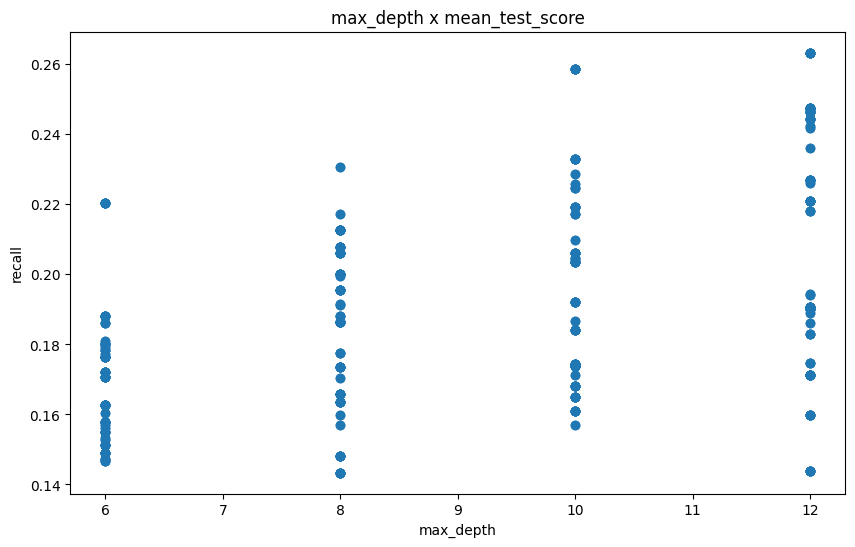

In [66]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,6))
plt.scatter(
    dt_gs_results['param_max_depth'],
    dt_gs_results['mean_test_score']
)

plt.title('max_depth x mean_test_score')
plt.xlabel('max_depth')
plt.ylabel('recall')
plt.show()

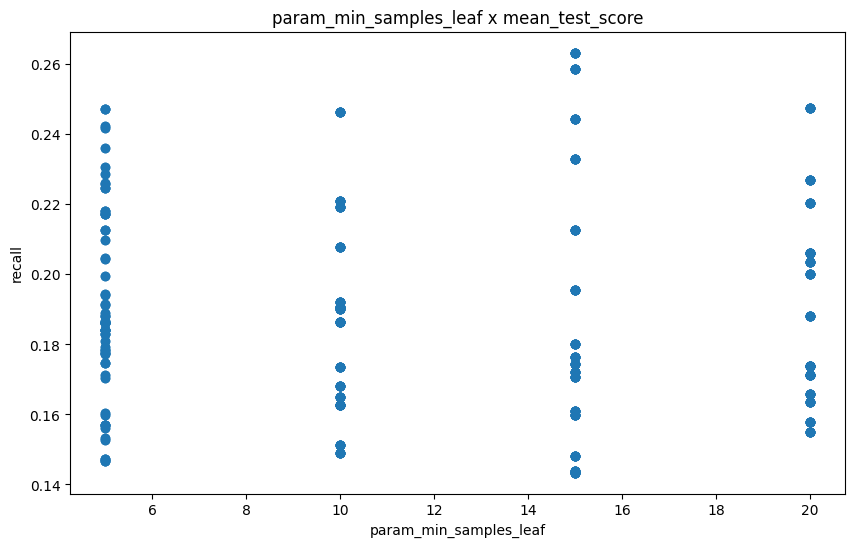

In [67]:
plt.figure(figsize=(10,6))
plt.scatter(
    dt_gs_results['param_min_samples_leaf'],
    dt_gs_results['mean_test_score']
)

plt.title('param_min_samples_leaf x mean_test_score')
plt.xlabel('param_min_samples_leaf')
plt.ylabel('recall')
plt.show()

###  Busca em grade para o LogisticRegression

In [68]:
max_iter = np.linspace(100,300,5, dtype=int)
c = [0.001, 0.01, 0.1, 1, 10]

param_grid_lr = [
    {'logisticregression__solver': ['newton-cg', 'lbfgs'],
     'logisticregression__penalty': ['l2'],
     'logisticregression__max_iter': max_iter,
     'logisticregression__C': c},
    {'logisticregression__solver': ['liblinear'],
     'logisticregression__penalty': ['l1','l2'],
     'logisticregression__max_iter': max_iter,
     'logisticregression__C': c}
    ]

In [69]:
lr_grid_search = GridSearchCV(
    estimator=make_pipeline(StandardScaler(),LogisticRegression(random_state=RANDOM_STATE)),
    param_grid=param_grid_lr,
    scoring='recall',
    n_jobs=-1,
    cv= cv,
    verbose=0
)

lr_grid_search.fit(X_treino, y_treino)

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceA

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__max_iter': array([100, 1...00, 250, 300]), 'logisticregression__penalty': ['l2'], 'logisticregression__solver': ['newton-cg', 'lbfgs']}, {'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__max_iter': array([100, 1...00, 250, 300]), 'logisticregression__penalty': ['l1', 'l2'], 'logisticregression__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide 

In [70]:
lr_grid_search.best_params_

{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [71]:
lr_gs_results = pd.DataFrame(lr_grid_search.cv_results_)
lr_gs_results.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008283,0.001306,0.002113,0.000074,0.001,100,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86
1,0.004108,0.000145,0.002090,0.000524,0.001,100,l2,lbfgs,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.113924,0.087025,0.079114,0.096835,0.012313,91
2,0.007508,0.000706,0.002053,0.000065,0.001,150,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86


In [72]:
lr_gs_results.loc[[lr_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
51,0.007092,0.00181,0.002989,0.00124,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


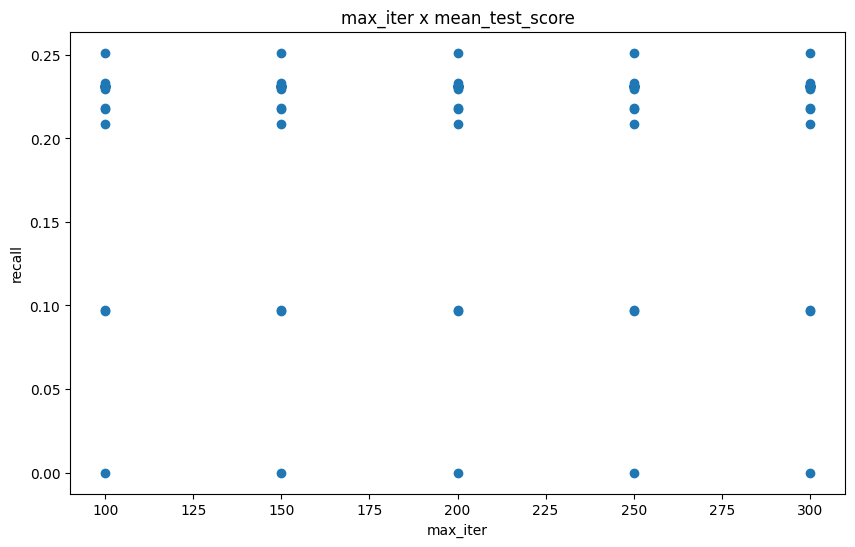

In [73]:
plt.figure(figsize=(10,6))
plt.scatter(
    lr_gs_results['param_logisticregression__max_iter'],
    lr_gs_results['mean_test_score']
)

plt.title('max_iter x mean_test_score')
plt.xlabel('max_iter')
plt.ylabel('recall')
plt.show()

## Validação cruzada aninhada

### Decision Tree Classifier

In [74]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [75]:
from sklearn.model_selection import cross_val_score

dt_nested_gs = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='recall',
    n_jobs=-1,
    cv= inner_cv,
    verbose=0
)

dt_nested_scores = cross_val_score(dt_nested_gs, X_treino, y_treino, cv=outer_cv)

In [47]:
print(f'Resultado de cada iteração do cv externo: {dt_nested_scores}')
print(f'média: {dt_nested_scores.mean():.4f}')

Resultado de cada iteração do cv externo: [0.23646724 0.24762808 0.20607787]
média: 0.2301


## Busca aleatória

### Decision Tree Classifier

In [76]:
from sklearn.model_selection import RandomizedSearchCV

In [79]:
rs_dt = RandomizedSearchCV(
        estimator= DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_distributions=param_grid_dt,
        n_iter=100,
        scoring='recall',
        n_jobs=-1,
        cv=inner_cv,
        random_state=RANDOM_STATE
    )

rs_dt_nested_scores = cross_val_score(rs_dt, X_treino, y_treino, cv=outer_cv)

In [80]:
print(f'Resultado de cada iteração do cv externo: {rs_dt_nested_scores}')
print(f'média: {rs_dt_nested_scores.mean():.4f}')

Resultado de cada iteração do cv externo: [0.23646724 0.18975332 0.21272555]
média: 0.2130


In [82]:
rs_dt.fit(X_treino, y_treino)
rs_dt.best_params_

{'splitter': 'best',
 'min_samples_split': np.int64(5),
 'min_samples_leaf': np.int64(15),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'gini'}

### Regressão logística

In [84]:
rs_lr = RandomizedSearchCV(
        estimator= make_pipeline(StandardScaler(),LogisticRegression(random_state=RANDOM_STATE)),
        param_distributions= param_grid_lr,
        n_iter=100,
        scoring='recall',
        n_jobs=-1,
        cv=inner_cv,
        random_state=RANDOM_STATE
    )

lr_dt_nested_scores = cross_val_score(rs_lr, X_treino, y_treino, cv=outer_cv)

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceA

In [85]:
print(f'Resultado de cada iteração do cv externo: {lr_dt_nested_scores}')
print(f'média: {lr_dt_nested_scores.mean():.4f}')

Resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média: 0.2538


## Otimização Bayesiana

### Decision Tree  Classifier

In [87]:
from skopt.space import Real, Integer, Categorical

space_dt = {
    'criterion': Categorical(['gini','entropy']),
    'max_depth': Integer(6,12),
    'min_samples_split': Integer(5,20),
    'min_samples_leaf': Integer(5,20),
    'max_features': Categorical(['sqrt', 'log2']),
    'splitter': Categorical(['best', 'random'])
}


In [88]:
from skopt import BayesSearchCV

In [93]:
opt_dt = BayesSearchCV(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            search_spaces= space_dt,
            n_iter=100,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE
        )

bs_dt_ns = cross_val_score(opt_dt, X_treino, y_treino, cv=outer_cv)

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(11), np.str_('log2'), np.int64(20), np.int64(20), np.str_('best')] before, using random point ['gini', np.int64(12), 'log2', np.int64(11), np.int64(10), 'best']
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(11), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['gini', np.int64(6), 'log2', np.int64(14), np.int64(7), 'random']
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has 

In [96]:
print(f'Resultado de cada iteração do cv externo: {bs_dt_ns}')
print(f'média: {bs_dt_ns.mean():.4f}')

Resultado de cada iteração do cv externo: [0.23931624 0.31973435 0.20702754]
média: 0.2554


In [97]:
opt_dt.fit(X_treino, y_treino)
opt_dt.best_params_

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(12), np.str_('sqrt'), np.int64(20), np.int64(20), np.str_('best')] before, using random point ['entropy', np.int64(12), 'log2', np.int64(14), np.int64(7), 'best']
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(12), np.str_('sqrt'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['gini', np.int64(10), 'sqrt', np.int64(9), np.int64(19), 'best']
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been 

OrderedDict([('criterion', 'entropy'),
             ('max_depth', 12),
             ('max_features', 'sqrt'),
             ('min_samples_leaf', 19),
             ('min_samples_split', 5),
             ('splitter', 'best')])

### Regressão logística

In [109]:
max_iter = Integer(100, 300)
c = Categorical([0.001, 0.01, 0.1, 1, 10])

space_lr = [
    {
        'logisticregression__solver': Categorical(['newton-cg', 'lbfgs']),
        'logisticregression__penalty': Categorical(['l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    },
    {
        'logisticregression__solver': Categorical(['liblinear']),
        'logisticregression__penalty': Categorical(['l1', 'l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    }
]

In [110]:
opt_lr = BayesSearchCV(
            estimator=make_pipeline(StandardScaler(),LogisticRegression()),
            search_spaces= space_lr,
            n_iter=50,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE
        )

bs_lr_ns = cross_val_score(opt_lr, X_treino, y_treino, cv=outer_cv)

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceA

In [111]:
print(f'Resultado de cada iteração do cv externo: {bs_lr_ns}')
print(f'média: {bs_lr_ns.mean():.4f}')

Resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média: 0.2538


In [112]:
opt_lr.fit(X_treino, y_treino)
opt_lr.best_params_

/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceAlura/venv/.aluravenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matschualtz/Desktop/DataScience/Repositorios/DataScienceA

OrderedDict([('logisticregression__C', 0.001),
             ('logisticregression__max_iter', 150),
             ('logisticregression__penalty', 'l2'),
             ('logisticregression__solver', 'liblinear')])